In [1]:
import matplotlib.pyplot as plt
from elfdannagalac.dmspectrum import dmspectra
import numpy as np

# Electron spectrum from DM annihilation
## Spectrum using cosmiXs

The following notebook shows how to use the `dmspectrum` class to get the electron-poistron ($e^{+}e^{-}$) spectrum from annihilation or decay of dark matter (DM) particles. We use the data from the projects `cosmiXs` and `pppc4dmid`. In both cases, the data give the number of electron/positron per $\log{x}$ interval, with $x=E_{kin}/m_{\chi}$. With that information we interpolate to energy and masses chosen by the user.

The `dmspectrum` class accepts the following parameters:

1. Mass of the DM candidate (GeV)
2. Minimum energy to compute the electron/positron spectrum (GeV)
3. Maximum energy to compute the electron/positron spectrum (GeV)
4. Annihilation/decay channel
5. Process (`keyword`): Annihilation (`anna`) or Decay (`decay`)
6. Project (`keyword`): `cosmixs` or `pppc4dmid`
7. Number of points (`keyword`)

Properties of the class can be accessed or modified using a variety of `getter` and `setter` methods.

`NOTE:` While we select a small value for the minimum energy to compute the spectra, we will only plot it in the GeV-TeV energy range. We also set the maximum energy to the 90% of available energy in the process

We will start by defining some values for parameters. I consider annihilation to $W$ bosons. The mass of the candidate is 10 TeV. The energy range is set to [$10^{-5},m_\chi$]. First, we select the project `cosmiXs`, but at the end, I show the comparison between `cosmiXs` and `pppc4dmid` projects, and also between annihilation and decay.

In [2]:
mass    = 1.e+4
emin    = 1.e-5
emax    = 0.90*mass
channel = 'W'

cosmix_spec = dmspectra.dmspectrum(mass,emin,emax,channel)

Min energy is below the allowed value
Setting to the min value 1.109e-05


Above, you can see that the initialization of the class take care of checking if the minimum and maximum energies are valid. We did not specify all the input parameters of the class, as they have some default values:

- project: `cosmiXs`
- process: `anna`
- npoints: 100

Now, we show how to get information about the different parameters of the spectrum class. To change the values, you can use the following syntax, for example:

```
cosmix_spec.mass = mass_value # In GeV
```

For more details about the methods, see the documentation (in process)

We check some properties of the spectrum that are related to the DM particle itself:

- mass
- annihilation or decay channel
- minimum energy
- maximum energy
- process
- data project

In [3]:
# Checking all the properties
cosmix_spec.mass

10000.0

In [4]:
cosmix_spec.channel

'W'

In [5]:
cosmix_spec.emin

1.109174815262401e-05

In [6]:
cosmix_spec.emax

9000.0

In [7]:
cosmix_spec.process

'anna'

In [8]:
cosmix_spec.dataproject

'cosmixs'

## Get the spectrum
To get the e-spectrum, then we simply call the method `spectrum`. Easy, peasy c:, right?.

This will return an array with the same length as the number of points in energy to compute the spectrum. The energy array is compute using log-steps, between `emin` and `emax` with `npoints`.

As we said before, the spectrum is computed using 2D-interpolation in mass and ${\rm{d}}N/{\rm{d}}\log{x}$, then we convert to the usual ${\rm d}N/{\rm d}E$, where $E$ refers to the kinetic energy of the electros (or positrons).

In [9]:
e_spectra = cosmix_spec.spectrum()

## Spectrum for PPPC4-DMID
The only two properties that are immutable in the class are the project and process used to compute the spectrum. So, if you want to compute the spectrum for the project `pppc4dmid`, you need to define a new instance of the class.

This was decided just for convenience, and avoid to update several parameters as the minimum energy. This can be useful if you want to compare between different masses and channels for the same project.

In [10]:
pppc4dmid_spec = dmspectra.dmspectrum(mass,emin,emax,channel,project='pppc4dmid')

Min energy is below the allowed value
Setting to the min value 1.259e-05


Then, we can obtain the spectrum in the same way as for the previous example.

In [11]:
e_pppc4dmid = pppc4dmid_spec.spectrum()

## Plotting

We can compare the e-spectrum from the two projects. If you are interested about the differences between both spectra, you can check the original references. Again, we only show the spectrum for kinetic energy of the electrons in the GeV-TeV range. Also, we chose the maximum energy to be 90% of the mass of the particle, just to avoid floating-rounding errors. This is necessary for some posterior calculations.

To access the energy array used to compute the spectrum we can use the property `engs`. c:

For this particular case, we can see that the spectrum obtained from `pppc4dmid` predicts a larger number of electrons for energies below 100 GeV, that can be considerable when computing the synchrotron and inverse compton photon flux in the ICM of galaxy clusters, for example. (We need to check this.)

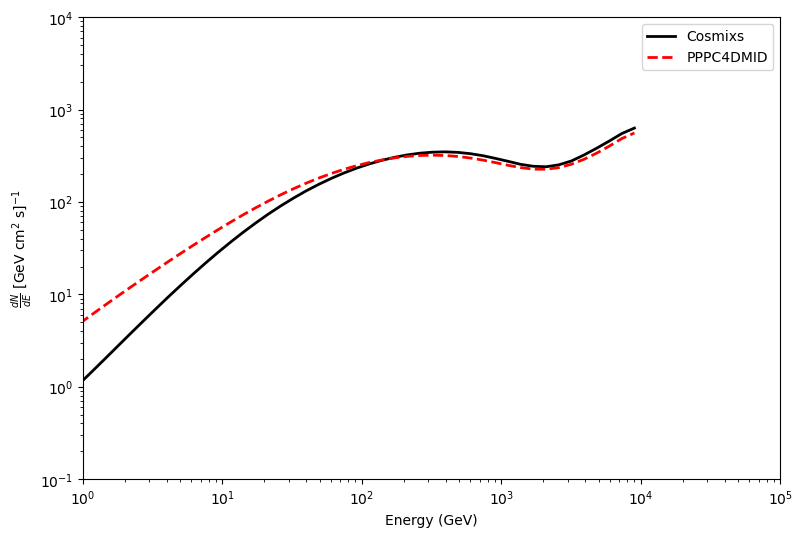

In [12]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(cosmix_spec.engs,cosmix_spec.engs**2*e_spectra,lw=2,color='black',label='Cosmixs')
ax.plot(pppc4dmid_spec.engs,pppc4dmid_spec.engs**2*e_pppc4dmid,lw=2,color='red',ls='--',label='PPPC4DMID')
ax.set_xlabel('Energy (GeV)')
ax.set_ylabel(r'$\frac{dN}{dE}$ [GeV cm$^2$ s]$^{-1}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1.0,1.e+5)
ax.set_ylim(1.e-1,1.e+4)
ax.legend()

# Electrom spectrum from DM decay

Now, we wil show how to compute the e-spectrum from decay of DM particles. The only difference is that the maximum energy will be set to 4 TeV. This is because the maximum energy disponible is the half of the mass of the DM particle.

`NOTE:` Both projects, `cosmiXs` and `pppc4dmid` do not provide the data for decay of DM particles. However, we assume that the process is exactly the same as we have now the annihilation of two DM particles with half mass of the particle we are interested. We need to apply an additioanl transofrmation for the $\log{x}$ term.

In [13]:
emax = 4e+3
cosmiXsdecay   = dmspectra.dmspectrum(mass,emin,emax,channel,process='decay')
decay_spectrum = cosmiXsdecay.spectrum()

Min energy is below the allowed value
Setting to the min value 1.109e-05


And now, plotting

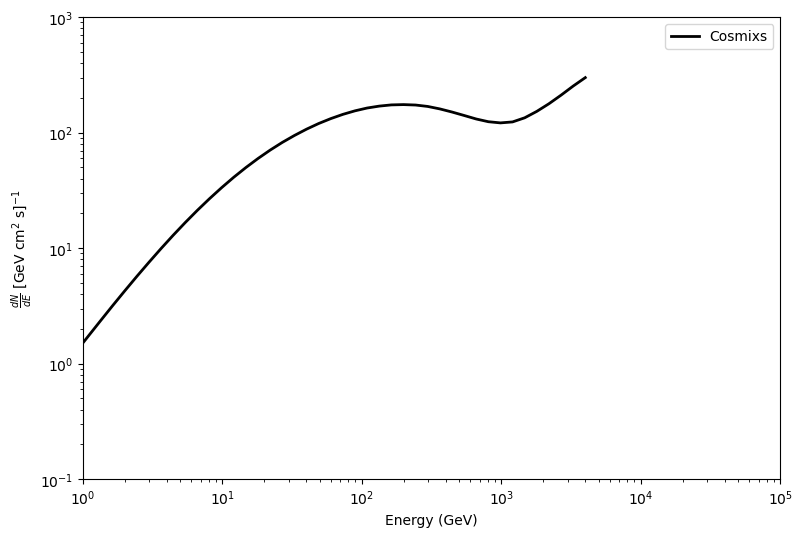

In [14]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(cosmiXsdecay.engs,cosmiXsdecay.engs**2*decay_spectrum,lw=2,color='black',label='Cosmixs')
ax.set_xlabel('Energy (GeV)')
ax.set_ylabel(r'$\frac{dN}{dE}$ [GeV cm$^2$ s]$^{-1}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1,1.e+5)
ax.set_ylim(1.e-1,1.e+3)
ax.legend()

We can compare also, between decay and annihilation for the `cosmiXs` project.

You can see that for decay the spectrum is `shifted` to the left, in concordance with the fact that the maximum energy is half the mass of the particle.

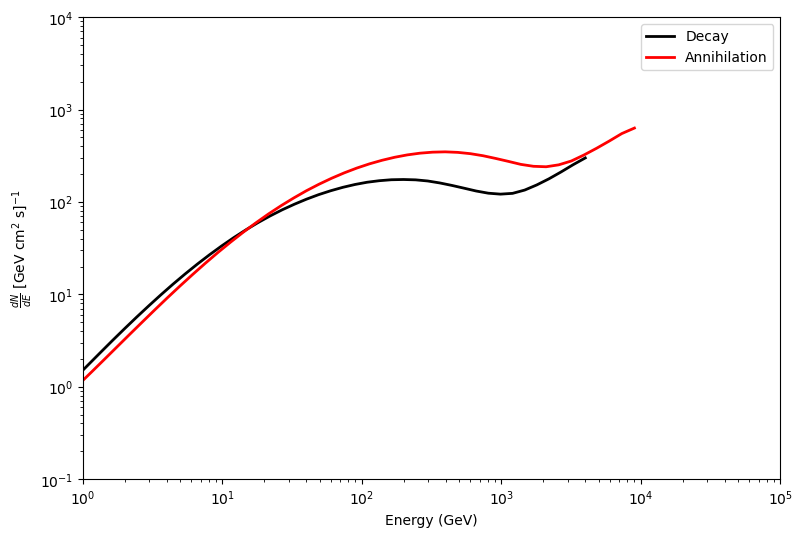

In [15]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(cosmiXsdecay.engs,cosmiXsdecay.engs**2*decay_spectrum,lw=2,color='black',label='Decay')
ax.plot(cosmix_spec.engs,cosmix_spec.engs**2*e_spectra,lw=2,color='red',label='Annihilation')
ax.set_xlabel('Energy (GeV)')
ax.set_ylabel(r'$\frac{dN}{dE}$ [GeV cm$^2$ s]$^{-1}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1.0,1.e+5)
ax.set_ylim(1.e-1,1.e+4)
ax.legend(loc='best')